<a href="https://colab.research.google.com/github/Xyrfo/Pembelajaran-Mesin/blob/main/JS05/tugas_lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Lab 2 - CountVectorizer vs TF-IDF

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay

## Load Data

In [2]:
from google.colab import files

uploaded = files.upload()
nama_file = next(iter(uploaded))
df = pd.read_csv(nama_file, encoding='latin-1')

# File spam.csv memiliki tiga kolom tambahan yang tidak digunakan.
df = df.iloc[:, :2]
df.columns = ['Labels', 'SMS']
df = df.dropna()

print('Ukuran data:', df.shape)
display(df.head())
print('Jumlah data per kelas:')
print(df['Labels'].value_counts())

df['Labels'] = df['Labels'].map({'ham': 0, 'spam': 1})
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['SMS'], df['Labels'], test_size=0.2, random_state=50, stratify=df['Labels']
)

Saving spam.csv to spam.csv
Ukuran data: (5572, 2)


,Labels,SMS
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Jumlah data per kelas:
Labels
ham     4825
spam     747
Name: count, dtype: int64


## CountVectorizer + MultinomialNB

              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.96      0.91      0.93       149

    accuracy                           0.98      1115
   macro avg       0.97      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



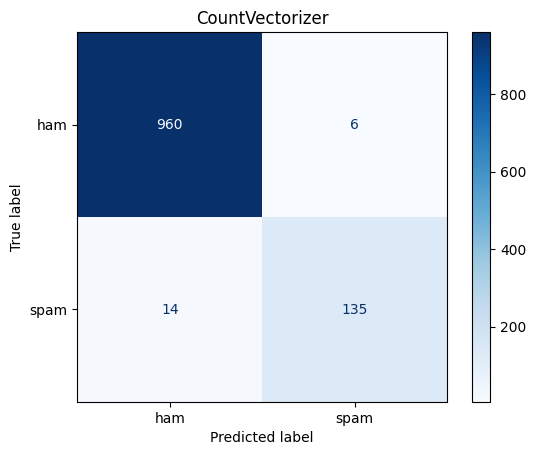

In [3]:
count_vec = CountVectorizer(stop_words='english')
train_count = count_vec.fit_transform(X_train_text)
test_count = count_vec.transform(X_test_text)
model_count = MultinomialNB().fit(train_count, y_train)
pred_count = model_count.predict(test_count)
print(classification_report(y_test, pred_count, target_names=['ham','spam']))
ConfusionMatrixDisplay.from_predictions(y_test, pred_count, display_labels=['ham','spam'], cmap='Blues')
plt.title('CountVectorizer')
plt.show()

## TF-IDF + MultinomialNB

              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       1.00      0.80      0.89       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115



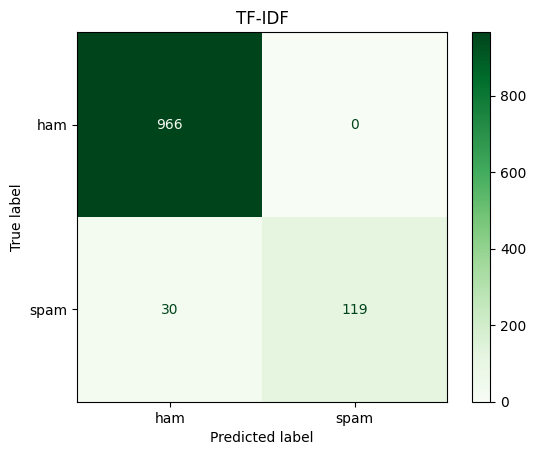

In [4]:
tfidf_vec = TfidfVectorizer(stop_words='english')
train_tfidf = tfidf_vec.fit_transform(X_train_text)
test_tfidf = tfidf_vec.transform(X_test_text)
model_tfidf = MultinomialNB().fit(train_tfidf, y_train)
pred_tfidf = model_tfidf.predict(test_tfidf)
print(classification_report(y_test, pred_tfidf, target_names=['ham','spam']))
ConfusionMatrixDisplay.from_predictions(y_test, pred_tfidf, display_labels=['ham','spam'], cmap='Greens')
plt.title('TF-IDF')
plt.show()

## Perbandingan dan Kesimpulan

,Fitur,Accuracy,Precision spam,Recall spam,F1 spam
0,CountVectorizer,0.9821,0.9574,0.9060,0.9310
1,TF-IDF,0.9731,1.0000,0.7987,0.8881


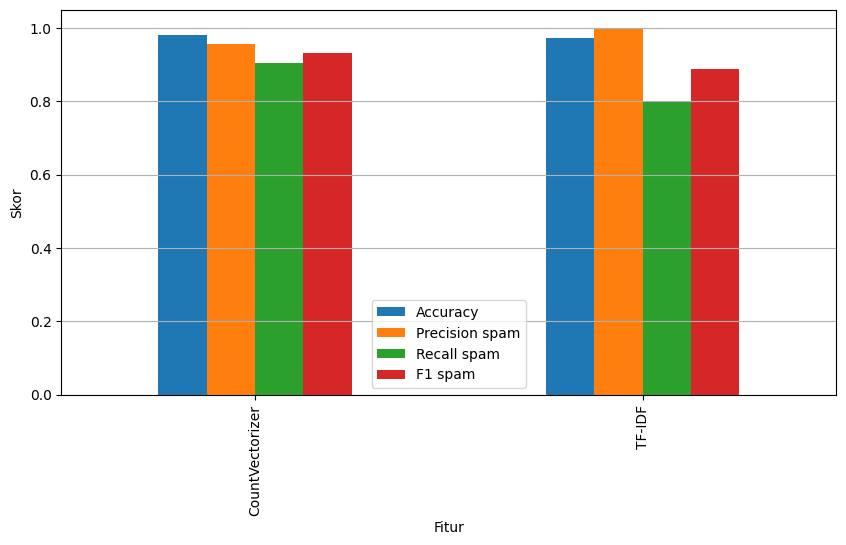

KESIMPULAN
Fitur terbaik berdasarkan F1-score spam: CountVectorizer
F1 CountVectorizer: 0.931
F1 TF-IDF: 0.8881


In [5]:
def score_row(nama, pred):
    return {'Fitur': nama, 'Accuracy': accuracy_score(y_test, pred), 'Precision spam': precision_score(y_test, pred), 'Recall spam': recall_score(y_test, pred), 'F1 spam': f1_score(y_test, pred)}
hasil = pd.DataFrame([score_row('CountVectorizer', pred_count), score_row('TF-IDF', pred_tfidf)])
display(hasil.round(4))
hasil.set_index('Fitur').plot(kind='bar', ylim=(0, 1.05), figsize=(10, 5))
plt.ylabel('Skor')
plt.grid(axis='y')
plt.show()
terbaik = hasil.loc[hasil['F1 spam'].idxmax(), 'Fitur']
print('KESIMPULAN')
print('Fitur terbaik berdasarkan F1-score spam:', terbaik)
print('F1 CountVectorizer:', round(hasil.loc[0, 'F1 spam'], 4))
print('F1 TF-IDF:', round(hasil.loc[1, 'F1 spam'], 4))